## Non-Convex Optimization: Exploring Local Minima with Multi-Start Search

This notebook demonstrates a common approach to finding local minima in non-convex optimization problems: **Multi-Start Optimization**. Unlike convex problems where any local minimum is also the global minimum, non-convex problems can have multiple local minima and saddle points, making the search for the absolute best solution challenging.

### The Problem: Himmelblau's Function

We are using **Himmelblau's function** as our objective function:

$f(x, y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2$

This function is a classic example in optimization for several reasons:
- **Non-convexity:** Its complex surface contains multiple "dips" or basins.
- **Known Local Minima:** It has four distinct local (and global) minima, all with a function value of 0. This makes it an excellent benchmark for algorithms designed to find multiple solutions.
- **Visualizability:** Being a 2D function (input `x`, `y`), its landscape can be easily visualized in 3D plots and 2D contour plots, allowing us to see the minima and the challenges of navigating its surface.

### The Approach: Multi-Start Optimization

The core idea is to run a local optimization algorithm from multiple, randomly generated starting points. Each local search will converge to *a* local minimum within its basin of attraction. By repeating this process many times, we increase the probability of discovering all or most of the significant local minima across the entire search space.

### Functions Implemented:

1.  **`objective_function(point)`:**
    *   **Purpose:** Evaluates Himmelblau's function at a given `[x, y]` point.
    *   **Role:** This is the function we aim to minimize.

2.  **`generate_random_start_point(bounds)`:**
    *   **Purpose:** Creates a random `[x, y]` coordinate within a specified rectangular search `bounds`.
    *   **Role:** Provides diverse starting points for the local search algorithm to explore different regions of the objective function's landscape.

3.  **`local_search(objective_func, initial_point, method, max_iter)`:**
    *   **Purpose:** Performs a single local optimization run using `scipy.optimize.minimize`.
    *   **Role:** Starting from an `initial_point`, it iteratively moves towards a local minimum within the immediate vicinity. We use the 'Nelder-Mead' method, a robust derivative-free algorithm suitable for many non-convex problems.

4.  **`is_close(point, list_of_points, tolerance)`:**
    *   **Purpose:** Checks if a newly found minimum is numerically close to any previously identified unique minima.
    *   **Role:** Essential for preventing the `multi_start_optimization` from reporting the same local minimum multiple times due to slight numerical differences in convergence.

5.  **`multi_start_optimization(objective_func, bounds, num_starts, tolerance, local_search_method, max_local_iter)`:**
    *   **Purpose:** Orchestrates the entire multi-start process.
    *   **Role:** It repeatedly calls `generate_random_start_point` and `local_search`. It then uses `is_close` to aggregate and report only the truly unique local minima found, sorted by their objective function values.

### Brute-Force Optimization (for comparison)

This method provides a simpler, albeit computationally more expensive, way to locate local minima by directly scanning the search space. It works by:
1.  **Discretizing the Search Space:** Creating a regular grid of points across the defined `bounds`.
2.  **Evaluating Every Point:** Calculating the objective function value for each point on the grid.
3.  **Neighbor Comparison:** For each point, comparing its value to all its immediate neighbors on the grid. If a point's value is lower than all its neighbors, it's considered a local minimum within that discretized grid.

While straightforward, the accuracy of this method depends heavily on the `num_points_per_dim` (grid resolution). A finer grid will yield more accurate results but at a higher computational cost.

#### Functions Implemented (Brute-Force):

1.  **`create_value_grid(objective_func, x_vals, y_vals)`:**
    *   **Purpose:** Builds a 2D array (grid) containing the objective function value for each `(x, y)` coordinate on the discretized grid.
    *   **Role:** Prepares the data for efficient neighbor comparison.

2.  **`check_is_local_minimum_on_grid(i, j, Z_grid, tolerance)`:**
    *   **Purpose:** Determines if a specific grid point at `(i, j)` is a local minimum by comparing its value to its 8 surrounding neighbors.
    *   **Role:** The core logic for identifying local minima in the brute-force approach.

3.  **`brute_force_optimization(objective_func, bounds, num_points_per_dim, uniqueness_tolerance, value_tolerance)`:**
    *   **Purpose:** Manages the entire brute-force search process.
    *   **Role:** Calls `create_value_grid`, iterates through the grid using `check_is_local_minimum_on_grid`, and aggregates unique minima, similar to the multi-start method.


In [17]:
import numpy as np
from scipy.optimize import minimize
import time

def objective_function(point):
    """
    A classic non-convex function (Himmelblau's function) for demonstration.
    Has four known local minima.
    Input: point (numpy array or list) - [x, y]
    Output: function value at point [x, y]
    """
    x, y = point
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def generate_random_start_point(bounds):
    """
    Generates a random starting point within specified bounds.
    Input: bounds (list of tuples) - e.g., [(min_x, max_x), (min_y, max_y)]
    Output: numpy array representing a random point.
    """
    return np.array([np.random.uniform(low, high) for low, high in bounds])

def local_search(objective_func, initial_point, method='Nelder-Mead', max_iter=1000):
    """
    Performs a local search to find a local minimum starting from initial_point.
    Uses scipy.optimize.minimize.
    Input:
        objective_func: The function to minimize.
        initial_point: The starting point for the search.
        method: Optimization method (e.g., 'Nelder-Mead', 'BFGS').
        max_iter: Maximum iterations for the local optimizer.
    Output:
        Tuple: (local_minimum_point, local_minimum_value) or (None, None) if unsuccessful.
    """
    result = minimize(objective_func, initial_point, method=method,
                      options={'maxiter': max_iter})
    if result.success:
        return result.x, result.fun
    else:
        return None, None # Optimization did not converge successfully

def is_close(point, list_of_points, tolerance=1e-3):
    """
    Checks if 'point' is approximately equal to any point in 'list_of_points'.
    Useful for identifying unique local minima.
    Input:
        point: The point to check.
        list_of_points: A list of points to compare against.
        tolerance: Maximum distance for points to be considered 'close'.
    Output: Boolean.
    """
    for p in list_of_points:
        if np.linalg.norm(np.array(point) - np.array(p)) < tolerance:
            return True
    return False

def multi_start_optimization(objective_func, bounds, num_starts=100, tolerance=1e-3, local_search_method='Nelder-Mead', max_local_iter=1000):
    """
    Performs multi-start optimization to find multiple local minima
    of a non-convex function.
    Input:
        objective_func: The non-convex function to minimize.
        bounds: Search space bounds, e.g., [(-5, 5), (-5, 5)].
        num_starts: Number of random starting points.
        tolerance: Tolerance for considering minima as unique.
        local_search_method: Method for `scipy.optimize.minimize`.
        max_local_iter: Max iterations for each local search.
    Output:
        Tuple: (list_of_unique_minima_points, list_of_unique_minima_values).
    """
    found_minima = []
    found_values = []

    for _ in range(num_starts):
        start_point = generate_random_start_point(bounds)
        local_min_point, local_min_val = local_search(objective_func, start_point,
                                                    method=local_search_method,
                                                    max_iter=max_local_iter)

        if local_min_point is not None:
            # Check if this minimum is new before adding
            if not is_close(local_min_point, found_minima, tolerance):
                found_minima.append(local_min_point)
                found_values.append(local_min_val)

    # Sort results by function value for easier analysis
    sorted_indices = np.argsort(found_values)
    sorted_minima = [found_minima[i] for i in sorted_indices]
    sorted_values = [found_values[i] for i in sorted_indices]

    return sorted_minima, sorted_values

def create_value_grid(objective_func, x_vals, y_vals):
    """Creates a 2D grid of function values for the given x and y ranges."""
    num_x = len(x_vals)
    num_y = len(y_vals)
    Z_grid = np.zeros((num_y, num_x))
    for i in range(num_y):
        for j in range(num_x):
            point = np.array([x_vals[j], y_vals[i]])
            Z_grid[i, j] = objective_func(point)
    return Z_grid

def check_is_local_minimum_on_grid(i, j, Z_grid, tolerance=1e-6):
    """Checks if a point (i, j) is a local minimum on the Z_grid."""
    num_y, num_x = Z_grid.shape
    current_value = Z_grid[i, j]

    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue

            ni, nj = i + di, j + dj
            if 0 <= ni < num_y and 0 <= nj < num_x:
                if Z_grid[ni, nj] < current_value - tolerance:
                    return False
    return True

def brute_force_optimization(objective_func, bounds, num_points_per_dim, uniqueness_tolerance=1e-3, value_tolerance=1e-6):
    """
    Performs a brute-force search to find local minima on a grid.
    Input:
        objective_func: The function to minimize.
        bounds: Search space bounds, e.g., [(-5, 5), (-5, 5)].
        num_points_per_dim: Number of points along each dimension for the grid.
        uniqueness_tolerance: Tolerance for considering minima points as unique.
        value_tolerance: Tolerance for comparing values on the grid.
    Output:
        Tuple: (list_of_unique_minima_points, list_of_unique_minima_values).
    """
    x_min, x_max = bounds[0]
    y_min, y_max = bounds[1]
    x_vals = np.linspace(x_min, x_max, num_points_per_dim)
    y_vals = np.linspace(y_min, y_max, num_points_per_dim)

    Z_grid = create_value_grid(objective_func, x_vals, y_vals)

    bf_minima_points = []
    bf_minima_values = []

    for i in range(len(y_vals)):
        for j in range(len(x_vals)):
            if check_is_local_minimum_on_grid(i, j, Z_grid, value_tolerance):
                point = np.array([x_vals[j], y_vals[i]])
                if not is_close(point, bf_minima_points, uniqueness_tolerance):
                    bf_minima_points.append(point)
                    bf_minima_values.append(Z_grid[i, j])

    # Sort results by function value
    sorted_indices = np.argsort(bf_minima_values)
    sorted_minima = [bf_minima_points[idx] for idx in sorted_indices]
    sorted_values = [bf_minima_values[idx] for idx in sorted_indices]

    return sorted_minima, sorted_values

# --- Example Usage ---
if __name__ == '__main__':
    # Define the search space bounds for Himmelblau's function (typically -5 to 5 for x and y)
    search_bounds = [(-5, 5), (-5, 5)]

    print("Starting multi-start optimization for Himmelblau's function...")
    start_time = time.perf_counter()
    unique_minima, unique_values = multi_start_optimization(
        objective_function,
        search_bounds,
        num_starts=200, # Increased starts to better explore the space
        tolerance=1e-2  # Adjust tolerance for uniqueness as needed
    )
    end_time = time.perf_counter()
    print(f"Multi-start optimization completed in {end_time - start_time:.4f} seconds.")

    print(f"Found {len(unique_minima)} unique local minima (Multi-Start):")
    for i, (minim_point, minim_value) in enumerate(zip(unique_minima, unique_values)):
        print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")

    print("\nStarting brute-force optimization for Himmelblau's function...")
    start_time = time.perf_counter()
    bf_unique_minima, bf_unique_values = brute_force_optimization(
        objective_function,
        search_bounds,
        num_points_per_dim=50, # A denser grid gives better approximation but is slower
        uniqueness_tolerance=1e-2,
        value_tolerance=1e-6
    )
    end_time = time.perf_counter()
    print(f"Brute-force optimization completed in {end_time - start_time:.4f} seconds.")

    print(f"Found {len(bf_unique_minima)} unique local minima (Brute-Force):")
    for i, (minim_point, minim_value) in enumerate(zip(bf_unique_minima, bf_unique_values)):
        print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")

    # Expected global minima for Himmelblau's function are at a value of 0:
    # (3, 2)
    # (-2.805118, 3.131312)
    # (-3.779310, -3.283186)
    # (3.584428, -1.848126)


Starting multi-start optimization for Himmelblau's function...
Multi-start optimization completed in 0.4242 seconds.
Found 4 unique local minima (Multi-Start):
Minimum 1: Point = [ 3.5844 -1.8481], Value = 0.000000
Minimum 2: Point = [-3.7793 -3.2832], Value = 0.000000
Minimum 3: Point = [3. 2.], Value = 0.000000
Minimum 4: Point = [-2.8051  3.1313], Value = 0.000000

Starting brute-force optimization for Himmelblau's function...
Brute-force optimization completed in 0.0130 seconds.
Found 4 unique local minima (Brute-Force):
Minimum 1: Point = [-2.7551  3.1633], Value = 0.123663
Minimum 2: Point = [ 3.5714 -1.9388], Value = 0.142820
Minimum 3: Point = [2.9592 1.9388], Value = 0.172198
Minimum 4: Point = [-3.7755 -3.3673], Value = 0.330289


In [18]:
print("\n--- Testing with a Random 3D Function ---")

def random_objective_function(point, num_peaks=5):
    """
    Generates a sum of Gaussian-like functions to create a random, non-convex landscape.
    """
    x, y = point
    z = 0
    np.random.seed(42) # For reproducibility
    for _ in range(num_peaks):
        # Randomly generate center and amplitude for each 'peak' (or valley for minimization)
        center_x = np.random.uniform(-4, 4)
        center_y = np.random.uniform(-4, 4)
        amplitude = np.random.uniform(5, 20) # Controls depth of minima
        std_dev = np.random.uniform(0.5, 1.5) # Controls width of minima

        z += amplitude * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * std_dev**2))
    return z

# Define search bounds for the random function
random_search_bounds = [(-5, 5), (-5, 5)]

print("Starting multi-start optimization for random function...")
start_time = time.perf_counter()
random_unique_minima, random_unique_values = multi_start_optimization(
    random_objective_function,
    random_search_bounds,
    num_starts=300, # More starts for a more complex random function
    tolerance=1e-2
)
end_time = time.perf_counter()
print(f"Multi-start optimization completed in {end_time - start_time:.4f} seconds.")

print(f"Found {len(random_unique_minima)} unique local minima (Multi-Start for Random Function):")
for i, (minim_point, minim_value) in enumerate(zip(random_unique_minima, random_unique_values)):
    print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")

print("\nStarting brute-force optimization for random function...")
start_time = time.perf_counter()
random_bf_unique_minima, random_bf_unique_values = brute_force_optimization(
    random_objective_function,
    random_search_bounds,
    num_points_per_dim=80, # Denser grid for random function
    uniqueness_tolerance=1e-2,
    value_tolerance=1e-6
)
end_time = time.perf_counter()
print(f"Brute-force optimization completed in {end_time - start_time:.4f} seconds.")

print(f"Found {len(random_bf_unique_minima)} unique local minima (Brute-Force for Random Function):")
for i, (minim_point, minim_value) in enumerate(zip(random_bf_unique_minima, random_bf_unique_values)):
    print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")



--- Testing with a Random 3D Function ---
Starting multi-start optimization for random function...
Multi-start optimization completed in 3.2644 seconds.
Found 2 unique local minima (Multi-Start for Random Function):
Minimum 1: Point = [68.4777 15.6935], Value = 0.000000
Minimum 2: Point = [ -9.4013 -62.4679], Value = 0.000000

Starting brute-force optimization for random function...
Brute-force optimization completed in 0.5550 seconds.
Found 6 unique local minima (Brute-Force for Random Function):
Minimum 1: Point = [ 5. -5.], Value = 0.000012
Minimum 2: Point = [5. 5.], Value = 0.006946
Minimum 3: Point = [-5.  5.], Value = 0.009731
Minimum 4: Point = [-5.     1.962], Value = 0.013118
Minimum 5: Point = [ 5.     -1.3291], Value = 0.019430
Minimum 6: Point = [-5. -5.], Value = 0.391557


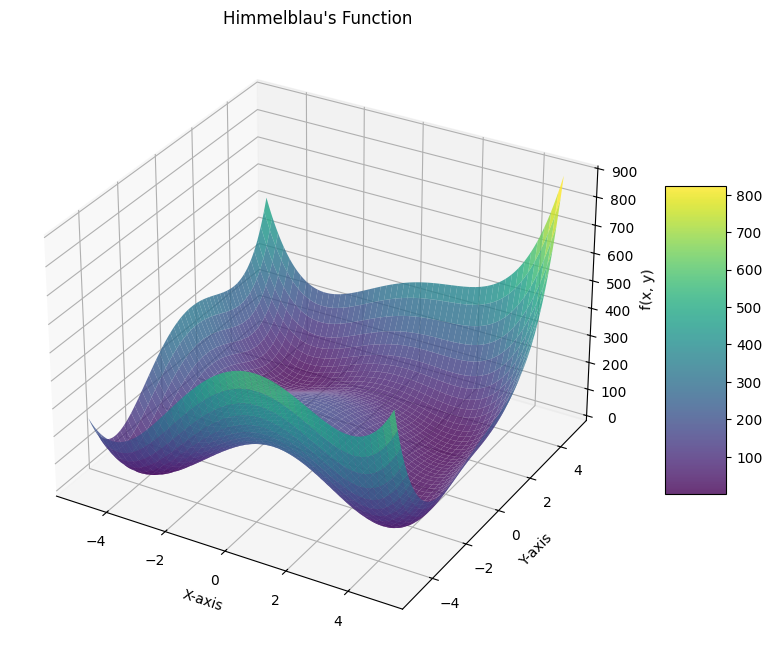

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a grid of x and y values
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

# Calculate Z values using the objective_function (Himmelblau's function)
Z = objective_function([X, Y])

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)

# Add labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('f(x, y)')
ax.set_title("Himmelblau's Function")

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

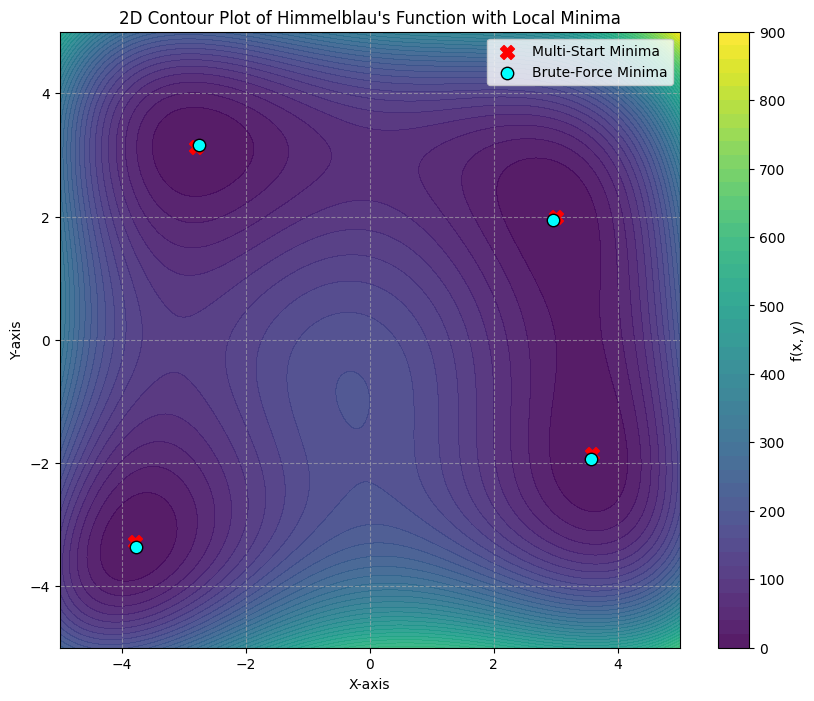

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Reuse the X, Y, Z data from the previous plot if available, or regenerate
# if the user runs this cell independently.
# (Assuming X, Y, Z are defined from the 3D plot cell above)
# If running this cell independently, ensure X, Y, Z are defined:
if 'X' not in locals() or 'Y' not in locals() or 'Z' not in locals():
    x_val = np.linspace(-5, 5, 200)
    y_val = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_val, y_val)
    Z = objective_function([X, Y])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

# Create a contour plot
contour = ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.9)

# Add a color bar
fig.colorbar(contour, ax=ax, label='f(x, y)')

# Plot the unique local minima found in the multi-start optimization
if 'unique_minima' in locals() and unique_minima:
    minima_x = [p[0] for p in unique_minima]
    minima_y = [p[1] for p in unique_minima]
    ax.scatter(minima_x, minima_y, color='red', marker='X', s=100, label='Multi-Start Minima', zorder=10)

# Plot the unique local minima found in the brute-force optimization
if 'bf_unique_minima' in locals() and bf_unique_minima:
    bf_minima_x = [p[0] for p in bf_unique_minima]
    bf_minima_y = [p[1] for p in bf_unique_minima]
    ax.scatter(bf_minima_x, bf_minima_y, color='cyan', marker='o', s=80, label='Brute-Force Minima', zorder=10, edgecolor='black')

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title("2D Contour Plot of Himmelblau's Function with Local Minima")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Testing with a Randomly Generated 3D Function

To further explore the capabilities of multi-start and brute-force optimization, we will now apply them to a randomly generated non-convex function. This function is created by summing several Gaussian-like peaks, resulting in a complex landscape with an unknown number of local minima. This provides a more challenging and less predictable test case compared to the well-known Himmelblau's function.

In [24]:
print("\n--- Testing with a Random 3D Function ---")

def random_objective_function(point, num_components=15):
    """
    Generates a sum of positive and negative Gaussian-like functions to create a random,
    non-convex landscape with both peaks and valleys.
    """
    x, y = point
    # Start with a flat base, or simply accumulate Z
    z = np.zeros_like(x, dtype=float) if isinstance(x, np.ndarray) else 0.0

    np.random.seed(42) # For reproducibility
    for _ in range(num_components):
        center_x = np.random.uniform(-20, 20)
        center_y = np.random.uniform(-20, 20)
        amplitude = np.random.uniform(5, 25) # Amplitude magnitude
        std_dev = np.random.uniform(3.0, 8.0) # Controls width/smoothness
        sign = np.random.choice([-1, 1]) # Randomly choose to create a peak or a valley

        z += sign * amplitude * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * std_dev**2))
    return z

# Define search bounds for the random function
random_search_bounds = [(-20, 20), (-20, 20)] # Expanded bounds

print("Starting multi-start optimization for random function...")
start_time = time.perf_counter()
random_unique_minima, random_unique_values = multi_start_optimization(
    random_objective_function,
    random_search_bounds,
    num_starts=1000, # More starts for a larger, more complex random function
    tolerance=1e-2
)
end_time = time.perf_counter()
print(f"Multi-start optimization completed in {end_time - start_time:.4f} seconds.")

print(f"Found {len(random_unique_minima)} unique local minima (Multi-Start for Random Function):")
for i, (minim_point, minim_value) in enumerate(zip(random_unique_minima, random_unique_values)):
    print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")

print("\nStarting brute-force optimization for random function...")
print("Note: Brute-force optimization over a larger domain with denser points may take longer.")
start_time = time.perf_counter()
random_bf_unique_minima, random_bf_unique_values = brute_force_optimization(
    random_objective_function,
    random_search_bounds,
    num_points_per_dim=150, # Denser grid for larger domain
    uniqueness_tolerance=1e-2,
    value_tolerance=1e-6
)
end_time = time.perf_counter()
print(f"Brute-force optimization completed in {end_time - start_time:.4f} seconds.")

print(f"Found {len(random_bf_unique_minima)} unique local minima (Brute-Force for Random Function):")
for i, (minim_point, minim_value) in enumerate(zip(random_bf_unique_minima, random_bf_unique_values)):
    print(f"Minimum {i+1}: Point = {np.round(minim_point, 4)}, Value = {minim_value:.6f}")


--- Testing with a Random 3D Function ---
Starting multi-start optimization for random function...
Multi-start optimization completed in 51.3772 seconds.
Found 2 unique local minima (Multi-Start for Random Function):
Minimum 1: Point = [-5.5016 18.2427], Value = -20.150495
Minimum 2: Point = [ -9.5648 -10.448 ], Value = -9.775047

Starting brute-force optimization for random function...
Note: Brute-force optimization over a larger domain with denser points may take longer.
Brute-force optimization completed in 13.7957 seconds.
Found 6 unique local minima (Brute-Force for Random Function):
Minimum 1: Point = [-5.5034 18.1208], Value = -20.146319
Minimum 2: Point = [-19.4631  20.    ], Value = -12.085869
Minimum 3: Point = [ -9.5302 -10.3356], Value = -9.772914
Minimum 4: Point = [20.      0.4027], Value = 2.997578
Minimum 5: Point = [ 20. -20.], Value = 8.613059
Minimum 6: Point = [20. 20.], Value = 10.614554


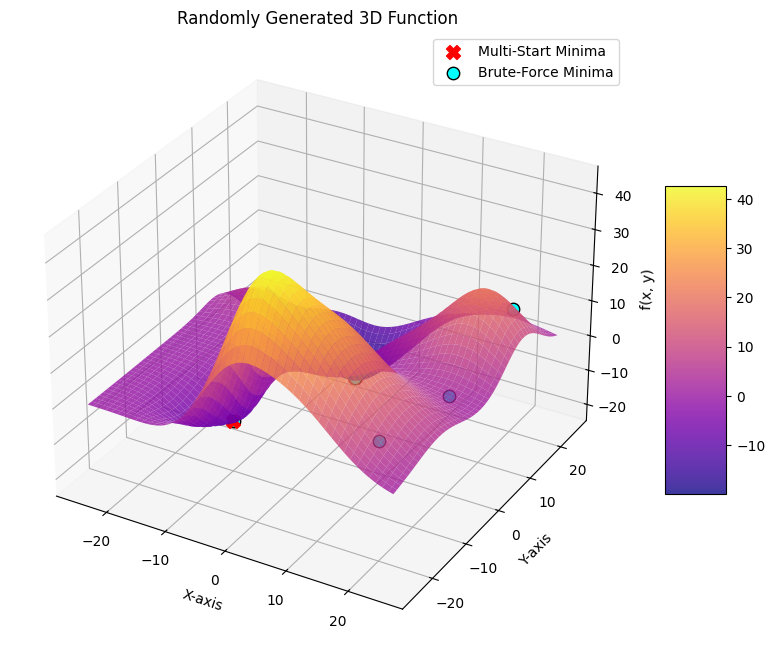

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Dynamically determine plot bounds based on found minima
# Initial bounds from random_search_bounds
current_min_x_bound, current_max_x_bound = random_search_bounds[0]
current_min_y_bound, current_max_y_bound = random_search_bounds[1]

# Start with these as the initial plot limits
x_plot_min = current_min_x_bound
x_plot_max = current_max_x_bound
y_plot_min = current_min_y_bound
y_plot_max = current_max_y_bound

# Collect all x and y coordinates of found minima
all_minima_x = []
all_minima_y = []

if 'random_unique_minima' in locals() and random_unique_minima:
    all_minima_x.extend([p[0] for p in random_unique_minima])
    all_minima_y.extend([p[1] for p in random_unique_minima])

if 'random_bf_unique_minima' in locals() and random_bf_unique_minima:
    all_minima_x.extend([p[0] for p in random_bf_unique_minima])
    all_minima_y.extend([p[1] for p in random_bf_unique_minima])

# Expand plot limits if any minima fall outside the initial search bounds
if all_minima_x:
    x_plot_min = min(x_plot_min, min(all_minima_x))
    x_plot_max = max(x_plot_max, max(all_minima_x))
if all_minima_y:
    y_plot_min = min(y_plot_min, min(all_minima_y))
    y_plot_max = max(y_plot_max, max(all_minima_y))

# Add a buffer to the calculated bounds for better visualization
buffer = 5.0 # Adjusted buffer
x_plot_min -= buffer
x_plot_max += buffer
y_plot_min -= buffer
y_plot_max += buffer

# Create a grid of x and y values for the random function using adjusted bounds
x_rand = np.linspace(x_plot_min, x_plot_max, 200)
y_rand = np.linspace(y_plot_min, y_plot_max, 200)
X_rand, Y_rand = np.meshgrid(x_rand, y_rand)

# Calculate Z values using the random_objective_function
Z_rand = random_objective_function([X_rand, Y_rand])

# Create the 3D plot
fig_rand_3d = plt.figure(figsize=(10, 8))
ax_rand_3d = fig_rand_3d.add_subplot(111, projection='3d')

# Plot the surface
surf_rand = ax_rand_3d.plot_surface(X_rand, Y_rand, Z_rand, cmap='plasma', edgecolor='none', alpha=0.8)

# Plot the unique local minima found in the multi-start optimization for random function
if 'random_unique_minima' in locals() and random_unique_minima:
    for i, (minim_point, minim_value) in enumerate(zip(random_unique_minima, random_unique_values)):
        # Ensure minim_point has correct dimensions for plotting as (x,y) coordinates
        x_coord = minim_point[0]
        y_coord = minim_point[1]
        z_coord = random_objective_function(minim_point) # Re-evaluate Z for exact minimum
        ax_rand_3d.scatter(x_coord, y_coord, z_coord, color='red', marker='X', s=100, label='Multi-Start Minima' if i == 0 else "", zorder=10)

# Plot the unique local minima found in the brute-force optimization for random function
if 'random_bf_unique_minima' in locals() and random_bf_unique_minima:
    for i, (minim_point, minim_value) in enumerate(zip(random_bf_unique_minima, random_bf_unique_values)):
        x_coord = minim_point[0]
        y_coord = minim_point[1]
        z_coord = random_objective_function(minim_point) # Re-evaluate Z for exact minimum
        ax_rand_3d.scatter(x_coord, y_coord, z_coord, color='cyan', marker='o', s=80, label='Brute-Force Minima' if i == 0 else "", zorder=10, edgecolor='black')

# Add labels and title
ax_rand_3d.set_xlabel('X-axis')
ax_rand_3d.set_ylabel('Y-axis')
ax_rand_3d.set_zlabel('f(x, y)')
ax_rand_3d.set_title("Randomly Generated 3D Function")

# Add a color bar
fig_rand_3d.colorbar(surf_rand, shrink=0.5, aspect=5)

ax_rand_3d.legend()
plt.show()

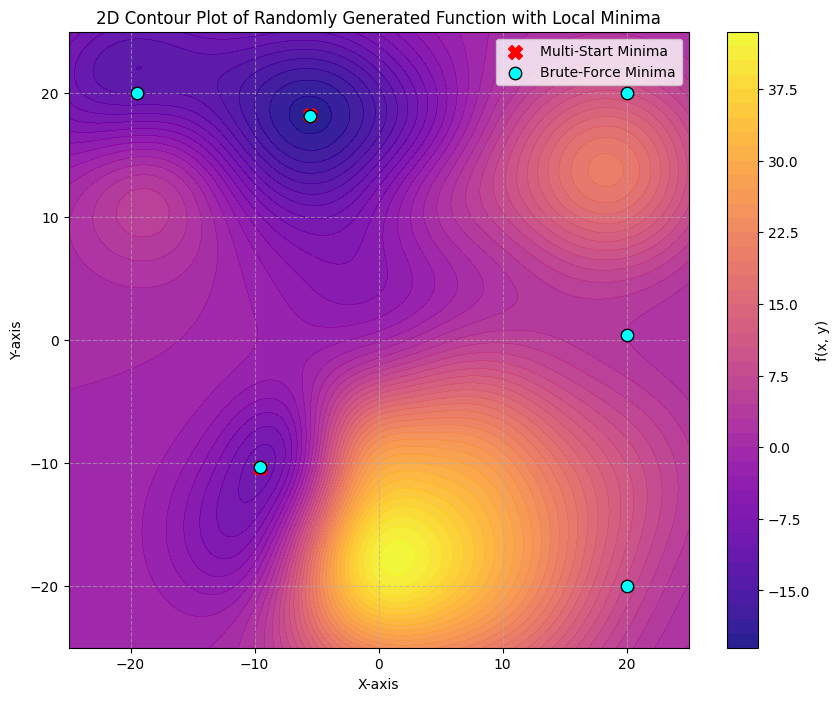

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Dynamically determine plot bounds based on found minima
# Initial bounds from random_search_bounds
current_min_x_bound, current_max_x_bound = random_search_bounds[0]
current_min_y_bound, current_max_y_bound = random_search_bounds[1]

# Start with these as the initial plot limits
x_plot_min = current_min_x_bound
x_plot_max = current_max_x_bound
y_plot_min = current_min_y_bound
y_plot_max = current_max_y_bound

# Collect all x and y coordinates of found minima
all_minima_x = []
all_minima_y = []

if 'random_unique_minima' in locals() and random_unique_minima:
    all_minima_x.extend([p[0] for p in random_unique_minima])
    all_minima_y.extend([p[1] for p in random_unique_minima])

if 'random_bf_unique_minima' in locals() and random_bf_unique_minima:
    all_minima_x.extend([p[0] for p in random_bf_unique_minima])
    all_minima_y.extend([p[1] for p in random_bf_unique_minima])

# Expand plot limits if any minima fall outside the initial search bounds
if all_minima_x:
    x_plot_min = min(x_plot_min, min(all_minima_x))
    x_plot_max = max(x_plot_max, max(all_minima_x))
if all_minima_y:
    y_plot_min = min(y_plot_min, min(all_minima_y))
    y_plot_max = max(y_plot_max, max(all_minima_y))

# Add a buffer to the calculated bounds for better visualization
buffer = 5.0 # Adjusted buffer
x_plot_min -= buffer
x_plot_max += buffer
y_plot_min -= buffer
y_plot_max += buffer

# Create a grid of x and y values for the random function using adjusted bounds
x_rand_val = np.linspace(x_plot_min, x_plot_max, 200)
y_rand_val = np.linspace(y_plot_min, y_plot_max, 200)
X_rand, Y_rand = np.meshgrid(x_rand_val, y_rand_val)
Z_rand = random_objective_function([X_rand, Y_rand])

fig_rand_2d = plt.figure(figsize=(10, 8))
ax_rand_2d = fig_rand_2d.add_subplot(111)

# Create a contour plot
contour_rand = ax_rand_2d.contourf(X_rand, Y_rand, Z_rand, levels=50, cmap='plasma', alpha=0.9)

# Add a color bar
fig_rand_2d.colorbar(contour_rand, ax=ax_rand_2d, label='f(x, y)')

# Plot the unique local minima found in the multi-start optimization for random function
if 'random_unique_minima' in locals() and random_unique_minima:
    rand_minima_x = [p[0] for p in random_unique_minima]
    rand_minima_y = [p[1] for p in random_unique_minima]
    ax_rand_2d.scatter(rand_minima_x, rand_minima_y, color='red', marker='X', s=100, label='Multi-Start Minima', zorder=10)

# Plot the unique local minima found in the brute-force optimization for random function
if 'random_bf_unique_minima' in locals() and random_bf_unique_minima:
    rand_bf_minima_x = [p[0] for p in random_bf_unique_minima]
    rand_bf_minima_y = [p[1] for p in random_bf_unique_minima]
    ax_rand_2d.scatter(rand_bf_minima_x, rand_bf_minima_y, color='cyan', marker='o', s=80, label='Brute-Force Minima', zorder=10, edgecolor='black')

ax_rand_2d.set_xlabel('X-axis')
ax_rand_2d.set_ylabel('Y-axis')
ax_rand_2d.set_title("2D Contour Plot of Randomly Generated Function with Local Minima")
ax_rand_2d.legend()
ax_rand_2d.grid(True, linestyle='--', alpha=0.6)
plt.show()